<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/DS/lamp/one_photon_at_a_time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Are we really working with one photon at a time?

Evgeny Kolonsky 2026

v.0.1.2


[Manual](https://github.com/evgeny-kolonsky/Lab4/blob/main/DS/2slit_man.pdf): TeachSpin TWS2-A, "Two-Slit Interference, One Photon at a Time".

**The question.** The manual, *Chapter 6 Section I* says the apparatus holds at most one photon at a time. Its argument starts from the PMT count rate. It assumes every PMT pulse is a photon, which is the thing we want to check. Thermal noise in the tube would give pulses too. The [expanded manual, Ch3.C pp.16-17](https://github.com/tphlabs/Lab4_DS_manual/blob/main/TeachSpin%20Two%20Slit%20Expanded%20Operating%20Manual.pdf) suggest lamp-to-detectort chain as an exercise.

**This notebook follows lamp-to-detector logic.** We start from the electrical power going into the bulb and follow the light forward through the green filter and the three slits. Nothing here uses the PMT, its quantum efficiency, or its counts.

**The result.** We found that that even at full power  lamp brightness the apparatus is working in a one-photon-at-a-time regime. The main contributors to photon count attenuation are green filter and the first slit.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c, h, k, e, pi


## Step 1. Electrical power of the bulb

The lamp is a Radion 1768: 6.0 V, 0.20 A (TWS2-A manual, Specifications). On one apparatus the lamp is replaced by other having power 1W.


In [14]:
V_bulb = 6.0     # V
I_bulb = 0.20    # A
P_el = V_bulb * I_bulb
print(f"P_el = {P_el:.2f} W")

P_el = 1.20 W


## Step 2. How much of that becomes light

An incandescent bulb turns a few percent of its electrical power into radiationthat leaves the envelope. We take 5%, which is an upper limit for a smalllow-voltage lamp. Every assumption in this notebook is chosen to *overestimate* the photon flux, so that the final number is an upper bound.

In [15]:
eta_bulb = 0.05
P_opt = eta_bulb * P_el
print(f"P_opt = {P_opt:.3f} W")

P_opt = 0.060 W


## Step 3. From energy to number of photons

We cannot divide by the energy of a green photon: most of the light from a hot filament is infrared, and those photons carry much less energy each. We need the *mean* photon energy of the spectrum. For a Planck spectrum of the black body the mean photon energy is    
$$\left<E\right> \approx    2.7  kT.$$
We consider the incandescent wolfram lamp as a black body radiation source.

Since $\left<E\right>$ is proportional to $T$, the photon yield per joule goes as $1/T$. Taking the *lowest* plausible filament temperature gives the *largest* photon count, so $T = 1800 K$ is the conservative choice. A filament this cool is barely glowing; we etimate ours lamp runs near 2260 K, and tungsten melts at 3695 K.

In [16]:
T_filament = 1800.0   # K, deliberately low = conservative
E_mean = 2.7 * k * T_filament
lam_equiv = h * c / E_mean
print(f"<E>      = {E_mean:.3e} J  ({E_mean/e:.3f} eV)")
print(f"equivalent wavelength = {lam_equiv*1e9:.0f} nm   (mid-infrared)")
print(f"photons per joule     = {1/E_mean:.3e}")

<E>      = 6.710e-20 J  (0.419 eV)
equivalent wavelength = 2960 nm   (mid-infrared)
photons per joule     = 1.490e+19


In [5]:
N_total = P_opt / E_mean
print(f"N_total = {N_total:.2e} photons/s emitted into 4*pi")

N_total = 8.94e+17 photons/s emitted into 4*pi


## Step 4. The green filter

The bulb light passes a narrow interference filter (546 nm, 10 nm FWHM) before reaching the slits. Only a tiny fraction of the photons get through. We measured this fraction with an Avantes AvaSpec-2048L: two spectra of the same lamp at full brightness, with and without the filter, each divided by its own integration time (see [notebook](https://github.com/evgeny-kolonsky/Lab4/blob/main/DS/lamp/Lamp_spectrum_measurements.ipynb)). Correcting both for the spectrometer response gives attenuation factor $8 \times 10^{-4}$. We round up to $10^{-3}$. This is an upper bound, because silicon is blind beyond 1100 nm, which is exactly where most of the filament's photons are. The true denominator is larger, so thetrue fraction is smaller.

In [17]:
green_filter = 1e-3
N_green = N_total * green_filter
print(f"N_green = {N_green:.2e} green photons/s into 4*pi")

N_green = 8.94e+14 green photons/s into 4*pi


## Step 5. The three apertures

Now pure geometry. All slits are 0.09 mm wide and about 10 mm tall (TWS2-A manual, Chapter 2).  

1. **Source slit**, about 100 mm from the filament. It catches a fraction   `area / (4*pi*r^2)` of the light emitted in all directions. This is by far the   biggest reduction.

2. **Double slit**. The beam has spread to roughly 1 cm x 1 cm by then; two slits   of 0.09 x 10 mm each catch 1.8 mm^2 out of 100 mm^2. 100mm^2 here is the sqaure of the light spot. The value is suggested in the manual; we accpet it. The light spot sqaure can be independently verified by estimating diffraction angle and distance from the slit to the spot.  

3. **Detector slit**. The beam spreads to about 1 cm x 1 cm again; one slit   catches 0.9 mm^2 out of 100 mm^2. Again, 100m^2 is the light spot sqaure.

In [19]:
slit_w = 0.09e-3     # m
slit_h = 10e-3       # m
r_bulb_slit = 0.100  # m, filament to source slit. Actually on the system#1 it is 145 mm. Again, we take conservative figure.

# 1. solid angle of the source slit
A_source = slit_w * slit_h
g1 = A_source / (4 * np.pi * r_bulb_slit**2)

# 2 and 3. the beam is ~1 cm x 1 cm = 100 mm^2 at both places
A_beam = 100.0                        # mm^2
g2 = 2 * (0.09 * 10) / A_beam         # two slits
g3 = (0.09 * 10) / A_beam             # one slit
print(f"g1 (source slit)   = {g1:.2e}")
print(f"g2 (double slit)   = {g2:.2e}")
print(f"g3 (detector slit) = {g3:.2e}")
print(f"product            = {g1*g2*g3:.2e}")

g1 (source slit)   = 7.16e-06
g2 (double slit)   = 1.80e-02
g3 (detector slit) = 9.00e-03
product            = 1.16e-09


In [20]:
n1 = N_green * g1
n2 = n1 * g2
n3 = n2 * g3

print(f"after source slit   : {n1:.2e} photons/s")
print(f"after double slit   : {n2:.2e} photons/s")
print(f"after detector slit : {n3:.2e} photons/s")

after source slit   : 6.40e+09 photons/s
after double slit   : 1.15e+08 photons/s
after detector slit : 1.04e+06 photons/s


## Step 6. How many photons are inside at once

A photon crosses the apparatus in $L/c$. Multiply that by the arrival rate to get the average number of photons in flight at any instant.
$$
\mu = I t = I \frac{L}{c}
$$
Here $\mu$ is the mean number of photons in flight,  $I$ = photons count rate, $t$ - photon flight time in apparatus of length $L$ with speed of light $c$.


In [22]:
L = 1.00            # m, optical path (TWS2-A specifications)
t_flight = L / c

mu = n3 * t_flight
spacing = c / n3    # average distance between photons along the beam
print(f"time of flight        = {t_flight*1e9:.2f} ns")
print(f"mu                    = {mu:.2e} mean number of photons in flight")
print(f"margin below mu = 1   = {1/mu:.0f}x")
print(f"spacing between photons = {spacing:.0f}m")

time of flight        = 3.34 ns
mu                    = 3.46e-03 mean number of photons in flight
margin below mu = 1   = 289x
spacing between photons = 289m


## Summary table

In [25]:
rows = [    ("electrical power",        f"{P_el:.2f} W"),   \
            ("optical power (5%)",      f"{P_opt:.3f} W"),  \
            ("mean photon energy",      f"{E_mean:.2e} J"), \
            ("photons emitted",         f"{N_total:.2e} 1/s"), \
            ("after green filter",      f"{N_green:.2e} 1/s"),  \
            ("after source slit",       f"{n1:.2e} 1/s"), \
            ("after double slit",       f"{n2:.2e} 1/s"),  \
            ("after detector slit",     f"{n3:.2e} 1/s"), \
            ("time of flight",          f"{t_flight*1e9:.1f} ns"),   \
            ("mean number of photons in flight",                      f"{mu:.1e}"),]
for name, val in rows:
  print(f"{name:<24}{val:>14}")

electrical power                1.20 W
optical power (5%)             0.060 W
mean photon energy          6.71e-20 J
photons emitted           8.94e+17 1/s
after green filter        8.94e+14 1/s
after source slit         6.40e+09 1/s
after double slit         1.15e+08 1/s
after detector slit       1.04e+06 1/s
time of flight                  3.3 ns
mean number of photons in flight       3.5e-03


## Conclusion

Mean number of photons in flight (occupancy) $\mu = 3.5 \times 10^{-3}$ at full lamp brightness. The apparatus is at least $290\times$ inside the one-photon-at-a-time regime. The chain used: conservation of energy, the Planck spectrum, one filter measurement, and three apertures measured with a ruler. It never used the PMT.

**Where the margin comes from.** The source slit does most of the work; it alone cuts the flux by 1.4e5. The filter contributes 1e3.

**How safe is the number.** Every assumption pushes the flux up:

| assumption | direction |
|---|---|
| bulb efficiency 5% | upper limit for an incandescent lamp |
| T = 1800 K | maximum photons per joule in the plausible range |
| filter factor 1e-3 | measured 8.0e-4, and that is itself an overestimate |
| isotropic emission | ignores the filament's own shadowing |
| 1 cm x 1 cm beam | the real spot at the detector slit is wider (~160 mm^2) |The one assumption pointing the other way: tungsten is a grey body with higheremissivity in the visible, so its true mean photon energy is ~10% above 2.701 kT.That *lowers* the photon count. Negligible against a 290x margin.

# Expected PMT count rate

Manual: Ch. 6, I (после п. 2c): "The claimed 'photon efficiency' of the PMT is only about 5%"

In [11]:
eta_PMT = 0.05
countrate_PMT = eta_PMT * n3
print(f'Imcoming photons countrate {n3:.1e} count/s')
print(f'PMT efficeincy {eta_PMT*100:.0f}%')
print(f'Expected PMT countrate top limit {countrate_PMT:.1e} count/s')


Imcoming photons countrate 1.0e+06 count/s
PMT efficeincy 5%
Expected PMT countrate top limit 5.2e+04 count/s


# Observed PMT countrate

Observed at two-slit mode at top fringe position at PNT voltage 500V.



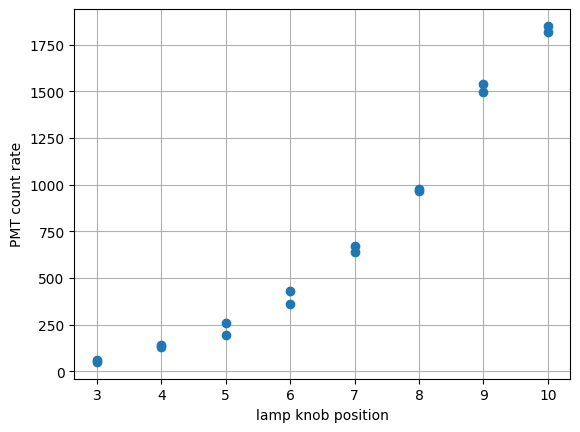

In [12]:
data = '''
# knob position, PMT countrate
10 1850
10 1815
9 1537
9 1496
8 968
8 975
7 640
7 670
6 430
6 362
5 194
5 258
4 130
4 140
3 60
3 50
'''

power, rate = np.genfromtxt(data.splitlines(), unpack=True)

plt.plot(power, rate, 'o')
plt.grid()
plt.xlabel('lamp knob position')
plt.ylabel('PMT count rate')
plt.show()